In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

sns.set(style="whitegrid")

# Paths

BASE_DIR = Path().resolve().parent  
ML_DIR = BASE_DIR / "ML_pipeline"
print("BASE_DIR:", BASE_DIR)
print("ML_DIR:", ML_DIR)

# Match interp_type to how you trained the model
interp_type = "kriging"  # "kriging" or "IDW"

if interp_type == "IDW":
    interp_type_folder = "withIDW_v4"
elif interp_type == "kriging":
    interp_type_folder = "withKriging_v4"
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

MODEL_OUT_DIR = ML_DIR / "model_artifacts" / interp_type_folder
GRAPHICS_DIR = MODEL_OUT_DIR / "graphics_evaluation"
GRAPHICS_DIR.mkdir(exist_ok=True, parents=True)

print("MODEL_OUT_DIR:", MODEL_OUT_DIR)
print("GRAPHICS_DIR:", GRAPHICS_DIR)

BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
ML_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline
MODEL_OUT_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withKriging_v4
GRAPHICS_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withKriging_v4\graphics_evaluation


In [2]:
# Consistent phase color scheme

PHASE_COLORS = {
    "Snow": "#1f77b4",   # blue
    "Rain": "#2ca02c",   # green
    "Mix":  "#e377c2"    # pink
}

PHASE_ORDER = ["Snow", "Rain", "Mix"]
PHASE_LABELS = {0: "Snow", 1: "Rain", 2: "Mix"}

sns.set_palette([PHASE_COLORS[p] for p in PHASE_ORDER])

In [3]:
# Load saved data

X_test = pd.read_parquet(MODEL_OUT_DIR / "X_test.parquet")
y_test_df = pd.read_parquet(MODEL_OUT_DIR / "y_test.parquet")
df_test_predictions = pd.read_parquet(MODEL_OUT_DIR / "test_predictions.parquet")

with open(MODEL_OUT_DIR / "model_metadata.json", "r") as f:
    metadata = json.load(f)

print("Loaded:")
print("  X_test:", X_test.shape)
print("  y_test_df:", y_test_df.shape)
print("  df_test_predictions:", df_test_predictions.shape)

print("Class mapping:", metadata.get("classes", {"0":"snow","1":"rain","2":"mix"}))


Loaded:
  X_test: (3919579, 6)
  y_test_df: (3919579, 1)
  df_test_predictions: (3919579, 11)
Class mapping: {'0': 'snow', '1': 'rain', '2': 'mix'}


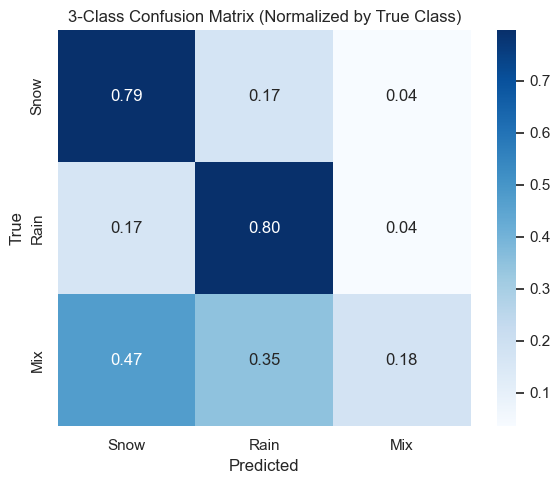

              precision    recall  f1-score   support

        Snow      0.613     0.795     0.692   1413694
        Rain      0.684     0.797     0.736   1555896
         Mix      0.607     0.176     0.272    949989

    accuracy                          0.646   3919579
   macro avg      0.635     0.589     0.567   3919579
weighted avg      0.640     0.646     0.608   3919579



In [4]:
assert len(df_test_predictions) == len(X_test)
assert len(df_test_predictions) == len(y_test_df)

# ==========================================
# 3-CLASS CONFUSION MATRIX
# ==========================================

y_true = df_test_predictions["phase"].values
y_pred = df_test_predictions["prediction"].values

labels = [0, 1, 2]
class_names = ["Snow", "Rain", "Mix"]

cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("3-Class Confusion Matrix (Normalized by True Class)")
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "confusion_matrix_3class.png", dpi=300)
plt.show()

print(classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=class_names,
    digits=3
))

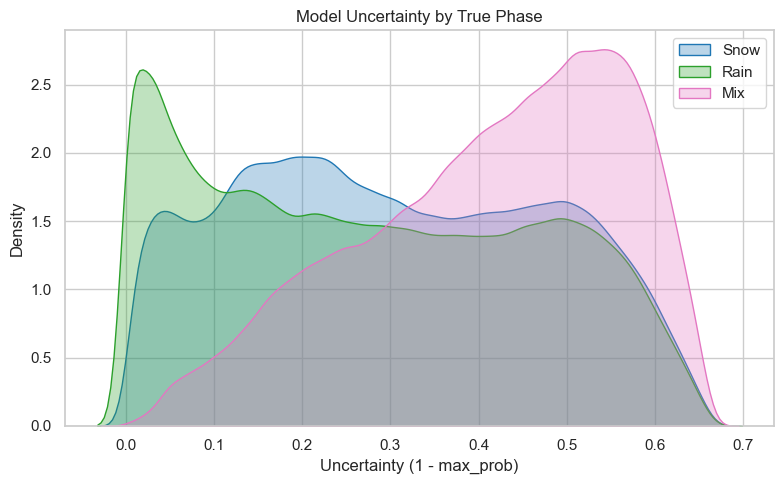

In [5]:
# ==========================================
# UNCERTAINTY DISTRIBUTION BY CLASS
# ==========================================

df_test_predictions["uncertainty"] = 1 - df_test_predictions["max_prob"]

plt.figure(figsize=(8,5))

for cls, label in zip([0,1,2], PHASE_ORDER):
    subset = df_test_predictions[df_test_predictions["phase"] == cls]
    sns.kdeplot(
        subset["uncertainty"],
        label=label,
        fill=True,
        alpha=0.3,
        color=PHASE_COLORS[label]
    )

plt.xlabel("Uncertainty (1 - max_prob)")
plt.ylabel("Density")
plt.title("Model Uncertainty by True Phase")
plt.legend()
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "uncertainty_by_true_class.png", dpi=300)
plt.show()

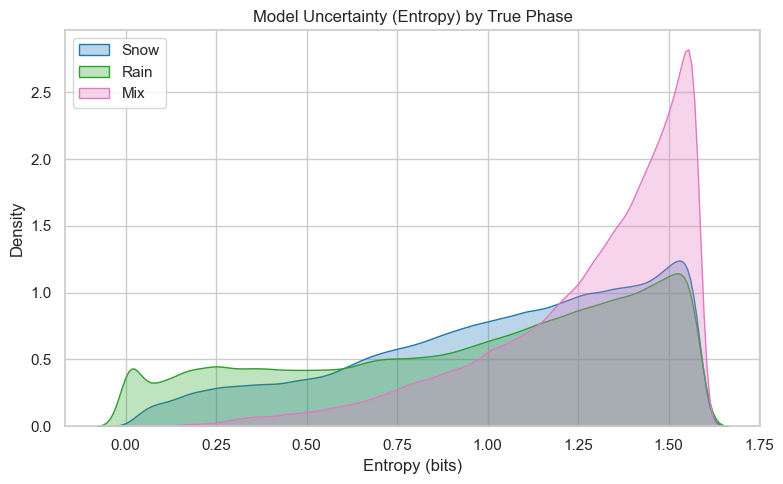

In [6]:
# ==========================================
# UNCERTAINTY DISTRIBUTION BY TRUE CLASS
# ==========================================

plt.figure(figsize=(8,5))

for cls, label in zip([0,1,2], PHASE_ORDER):
    subset = df_test_predictions[df_test_predictions["phase"] == cls]
    sns.kdeplot(
        subset["entropy"],
        label=label,
        fill=True,
        alpha=0.3,
        color=PHASE_COLORS[label]
    )

plt.xlabel("Entropy (bits)")
plt.ylabel("Density")
plt.title("Model Uncertainty (Entropy) by True Phase")
plt.legend()
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "entropy_by_true_class.png", dpi=300)
plt.show()

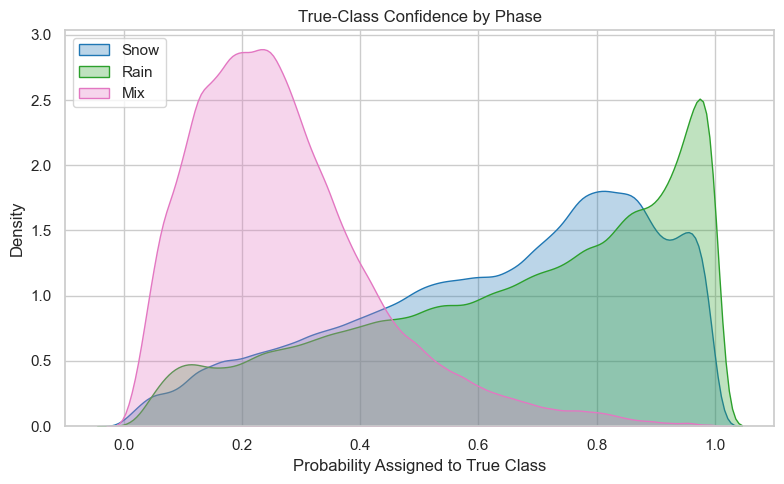

In [7]:
# ==========================================
# TRUE-CLASS PROBABILITY DISTRIBUTION
# ==========================================

df = df_test_predictions.copy()

df["p_true"] = np.where(
    df["phase"] == 0, df["p_snow"],
    np.where(
        df["phase"] == 1, df["p_rain"],
        df["p_mix"]
    )
)

plt.figure(figsize=(8,5))

for cls, label in zip([0,1,2], PHASE_ORDER):
    subset = df[df["phase"] == cls]
    sns.kdeplot(
        subset["p_true"],
        label=label,
        fill=True,
        alpha=0.3,
        color=PHASE_COLORS[label]
    )

plt.xlabel("Probability Assigned to True Class")
plt.ylabel("Density")
plt.title("True-Class Confidence by Phase")
plt.legend()
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "true_class_confidence_by_phase.png", dpi=300)
plt.show()

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_28232\2821284450.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_28232\2821284450.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(GRAPHICS_DIR / "probability_vs_wetbulb.png", dpi=300)
c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


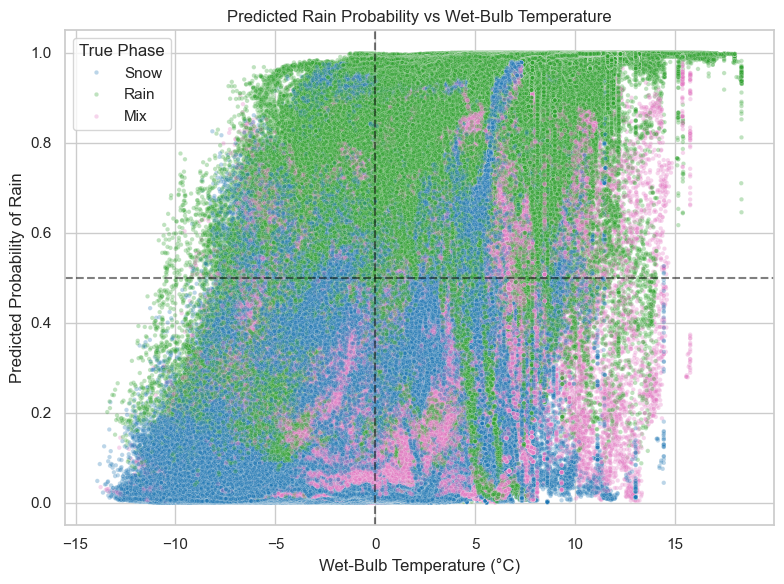

In [8]:
# ==========================================
# P_RAIN vs WET-BULB TEMPERATURE
# ==========================================

plt.figure(figsize=(8,6))

phase_labels = df_test_predictions["phase"].map(PHASE_LABELS)

sns.scatterplot(
    x=X_test["temp_wet"],
    y=df_test_predictions["p_rain"],
    hue=phase_labels,
    hue_order=PHASE_ORDER,
    palette=PHASE_COLORS,
    alpha=0.3,
    s=10
)

plt.axhline(0.5, linestyle="--", color="black", alpha=0.5)
plt.axvline(0.0, linestyle="--", color="black", alpha=0.5)

plt.xlabel("Wet-Bulb Temperature (°C)")
plt.ylabel("Predicted Probability of Rain")
plt.title("Predicted Rain Probability vs Wet-Bulb Temperature")
plt.legend(title="True Phase")
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "probability_vs_wetbulb.png", dpi=300)
plt.show()


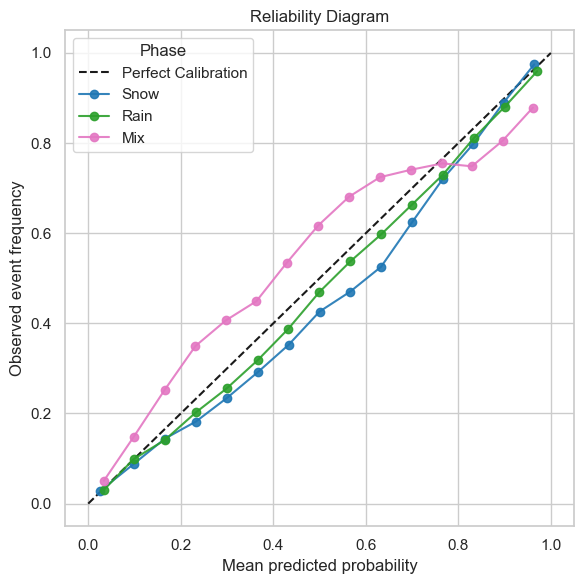

In [9]:
def reliability_curve(probs, y_true, target_class, n_bins=15):
    """
    Compute reliability curve for a single class.

    probs: 1D array of predicted probabilities for the target class
    y_true: 1D array of integer class labels (0,1,2)
    target_class: int (0 for Snow, 1 for Rain, 2 for Mix)
    """
    y_multi = (y_true == target_class).astype(int)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    obs_freq = []
    pred_mean = []
    counts = []

    for i in range(n_bins):
        idx = (probs >= bins[i]) & (probs < bins[i+1])
        if np.sum(idx) > 0:
            obs_freq.append(np.mean(y_multi[idx]))
            pred_mean.append(np.mean(probs[idx]))
            counts.append(np.sum(idx))
        else:
            obs_freq.append(np.nan)
            pred_mean.append(np.nan)
            counts.append(0)

    return np.array(pred_mean), np.array(obs_freq), np.array(counts), bin_centers


# p_snow and p_rain, p_mix
p_snow = df_test_predictions["p_snow"].to_numpy()
p_rain = df_test_predictions["p_rain"].to_numpy()
p_mix  = df_test_predictions["p_mix"].to_numpy()

y_true = df_test_predictions["phase"].to_numpy()  # integer labels 0/1/2


plt.figure(figsize=(6,6))

# Perfect calibration line
plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration")

phase_probs = {
    0: p_snow,
    1: p_rain,
    2: p_mix,
}

for cls in [0, 1, 2]:
    label = PHASE_LABELS[cls]
    color = PHASE_COLORS[label]

    pred_mean, obs_freq, counts, bin_centers = reliability_curve(
        phase_probs[cls],
        y_true,
        target_class=cls,
        n_bins=15
    )

    # Filter NaNs so they don't break the lines
    mask_valid = ~np.isnan(pred_mean) & ~np.isnan(obs_freq)
    plt.plot(
        pred_mean[mask_valid],
        obs_freq[mask_valid],
        "o-",
        label=f"{label}",
        color=color,
        alpha=0.9,
    )

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event frequency")
plt.title("Reliability Diagram")
plt.legend(title="Phase")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_28232\1294188144.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["tw_bin", "true"])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_28232\1294188144.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["tw_bin", "pred"])


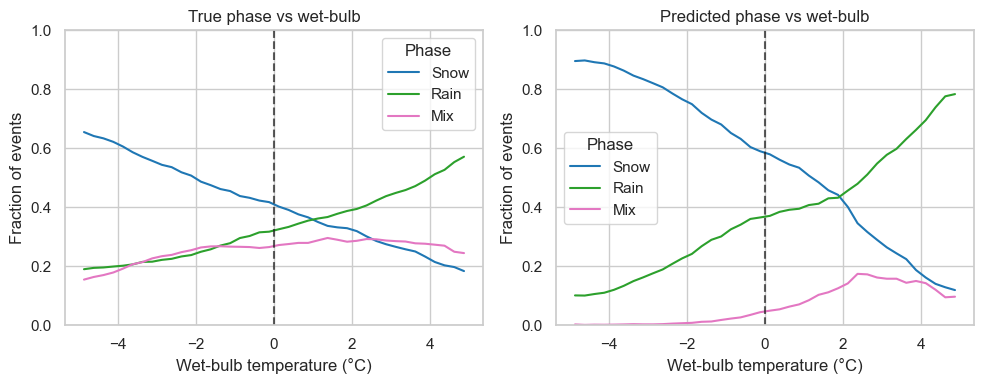

In [10]:
# =====================================================
# True vs predicted phase composition vs wet-bulb (MULTICLASS)
# =====================================================

# True labels: 0 = Snow, 1 = Rain, 2 = Mix
phase_col = "phase" if "phase" in df_test_predictions.columns else "phase_full"

# Pull arrays separately
temp_wet   = X_test["temp_wet"].to_numpy()
phase_true = df_test_predictions[phase_col].to_numpy()

# --- Get predicted phase as integers 0/1/2 ---
if "prediction" in df_test_predictions.columns:
    # Use existing integer predictions if present
    phase_pred = df_test_predictions["prediction"].to_numpy()
else:
    # Multiclass: derive from 3 softmax probabilities
    prob_cols_3 = ["p_snow", "p_rain", "p_mix"]
    if not all(c in df_test_predictions.columns for c in prob_cols_3):
        raise ValueError(
            "Multiclass run expected columns ['p_snow','p_rain','p_mix'] "
            "or a 'prediction' column."
        )
    probs = df_test_predictions[prob_cols_3].to_numpy()
    phase_pred = probs.argmax(axis=1)   # 0 = Snow, 1 = Rain, 2 = Mix

# Restrict to near-freezing window
mask = (temp_wet >= -5.0) & (temp_wet <= 5.0)

tw_nf     = temp_wet[mask]
true_nf   = phase_true[mask]
pred_nf   = phase_pred[mask]

# Temporary DataFrame for binning/normalizing
comp_df = pd.DataFrame({
    "temp_wet": tw_nf,
    "true": true_nf,
    "pred": pred_nf,
})

bins = np.linspace(-5, 5, 41)
comp_df["tw_bin"] = pd.cut(comp_df["temp_wet"], bins=bins)

# --- True fractions ---
true_frac = (
    comp_df
    .groupby(["tw_bin", "true"])
    .size()
    .unstack(fill_value=0)
)
true_frac = true_frac.div(true_frac.sum(axis=1), axis=0)

# --- Predicted fractions ---
pred_frac = (
    comp_df
    .groupby(["tw_bin", "pred"])
    .size()
    .unstack(fill_value=0)
)
pred_frac = pred_frac.div(pred_frac.sum(axis=1), axis=0)

bin_centers = np.array([interval.mid for interval in true_frac.index])

plt.figure(figsize=(10,4))

# Panel 1: True
plt.subplot(1,2,1)
for cls in [0, 1, 2]:
    label = PHASE_LABELS[cls]      # e.g. {0: "Snow", 1: "Rain", 2: "Mix"}
    if cls in true_frac.columns:
        plt.plot(
            bin_centers,
            true_frac[cls].values,
            label=label,
            color=PHASE_COLORS[label]   # Snow blue, Rain green, Mix pink
        )

plt.axvline(0.0, linestyle="--", alpha=0.7, color="k")
plt.ylim(0,1)
plt.xlabel("Wet-bulb temperature (°C)")
plt.ylabel("Fraction of events")
plt.title("True phase vs wet-bulb")
plt.legend(title="Phase", loc="best")

# Panel 2: Predicted
plt.subplot(1,2,2)
for cls in [0, 1, 2]:
    label = PHASE_LABELS[cls]
    if cls in pred_frac.columns:
        plt.plot(
            bin_centers,
            pred_frac[cls].values,
            label=label,
            color=PHASE_COLORS[label]
        )

plt.axvline(0.0, linestyle="--", alpha=0.7, color="k")
plt.ylim(0,1)
plt.xlabel("Wet-bulb temperature (°C)")
plt.ylabel("Fraction of events")
plt.title("Predicted phase vs wet-bulb")
plt.legend(title="Phase", loc="best")

plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "true_vs_pred_phase_vs_wetbulb.png", dpi=300)
plt.show()